# Customer Churn Prediction — End-to-End ML Pipeline
**Skills:** Python · Data Analytics · Data Science · Machine Learning · EDA · SHAP

## Imports

In [ ]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, os

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve, f1_score

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
RANDOM_STATE = 42
print('All libraries imported!')

All libraries imported!


## Load Data

In [ ]:
df = pd.read_csv('customer_churn_dataset-testing-master.csv')
print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Churn Rate: {df["Churn"].mean():.1%}')
df.head()

Shape: 64,374 rows x 12 columns
Churn Rate: 47.4%


,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,2,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,3,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,4,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,5,53,Female,58,24,9,2,Standard,Annual,533,18,0


## EDA: Churn Distribution

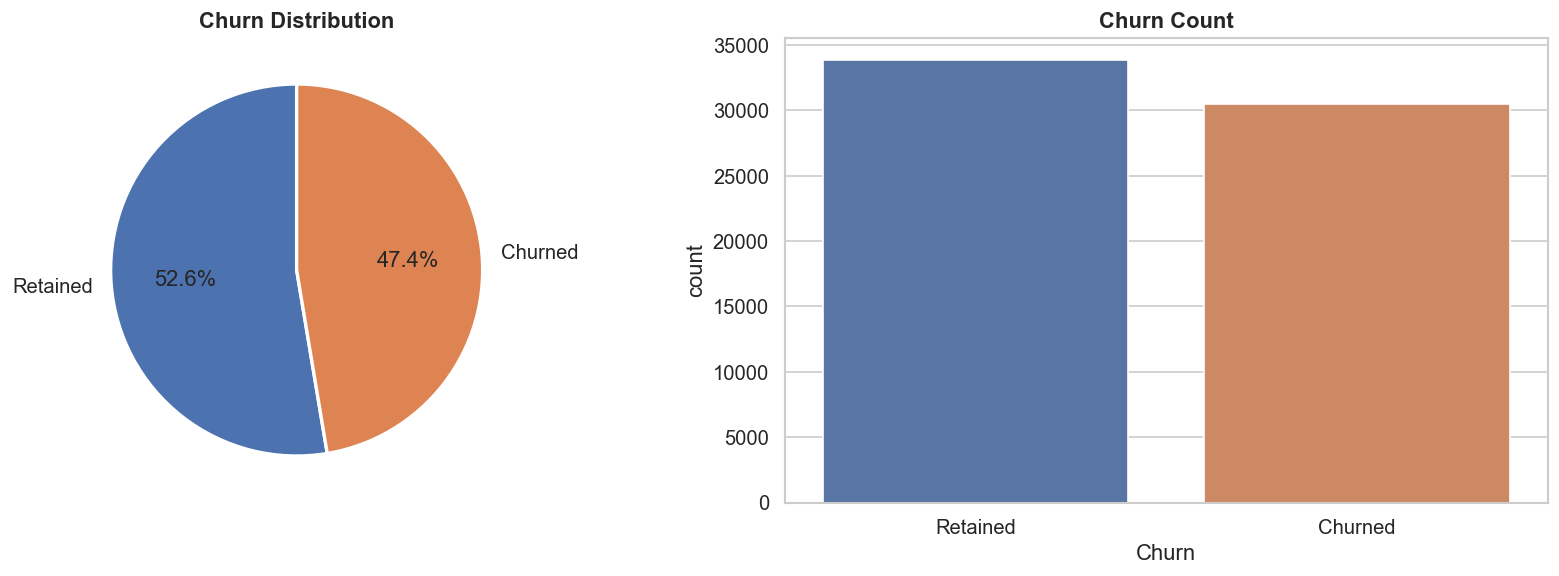

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
churn_counts = df['Churn'].value_counts()
colors = ['#4C72B0', '#DD8452']
axes[0].pie(churn_counts, labels=['Retained', 'Churned'], autopct='%1.1f%%',
            colors=colors, startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title('Churn Distribution', fontweight='bold')
sns.countplot(data=df, x='Churn', palette=colors, ax=axes[1])
axes[1].set_title('Churn Count', fontweight='bold')
axes[1].set_xticklabels(['Retained', 'Churned'])
plt.tight_layout()
plt.savefig('01_churn_distribution.png', bbox_inches='tight')
plt.show()

## EDA: Numeric Features vs Churn

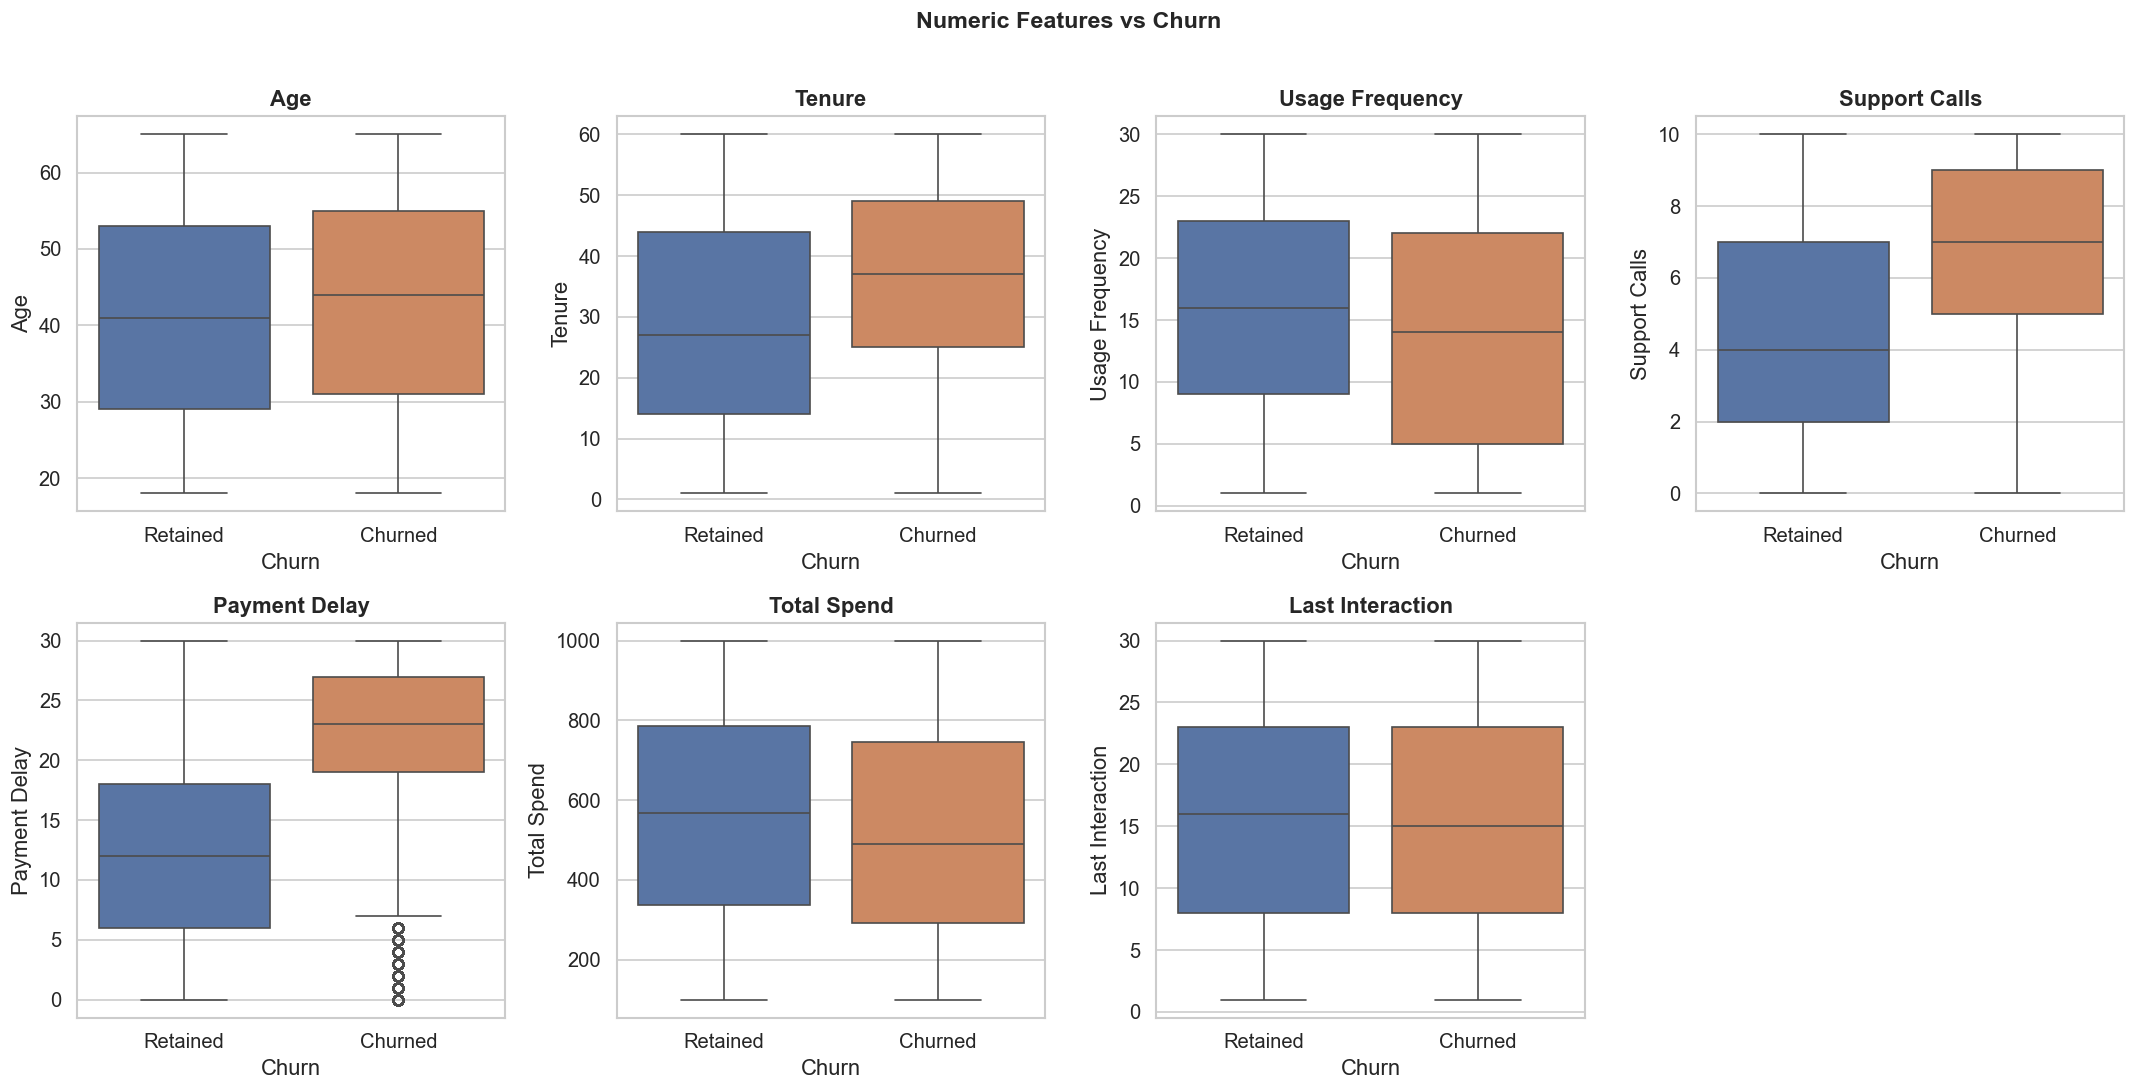

In [5]:
num_cols = ['Age', 'Tenure', 'Usage Frequency', 'Support Calls',
            'Payment Delay', 'Total Spend', 'Last Interaction']
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.boxplot(data=df, x='Churn', y=col, palette=['#4C72B0', '#DD8452'], ax=axes[i])
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xticklabels(['Retained', 'Churned'])
axes[-1].set_visible(False)
plt.suptitle('Numeric Features vs Churn', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('02_numeric_vs_churn.png', bbox_inches='tight')
plt.show()

## EDA: Categorical Features

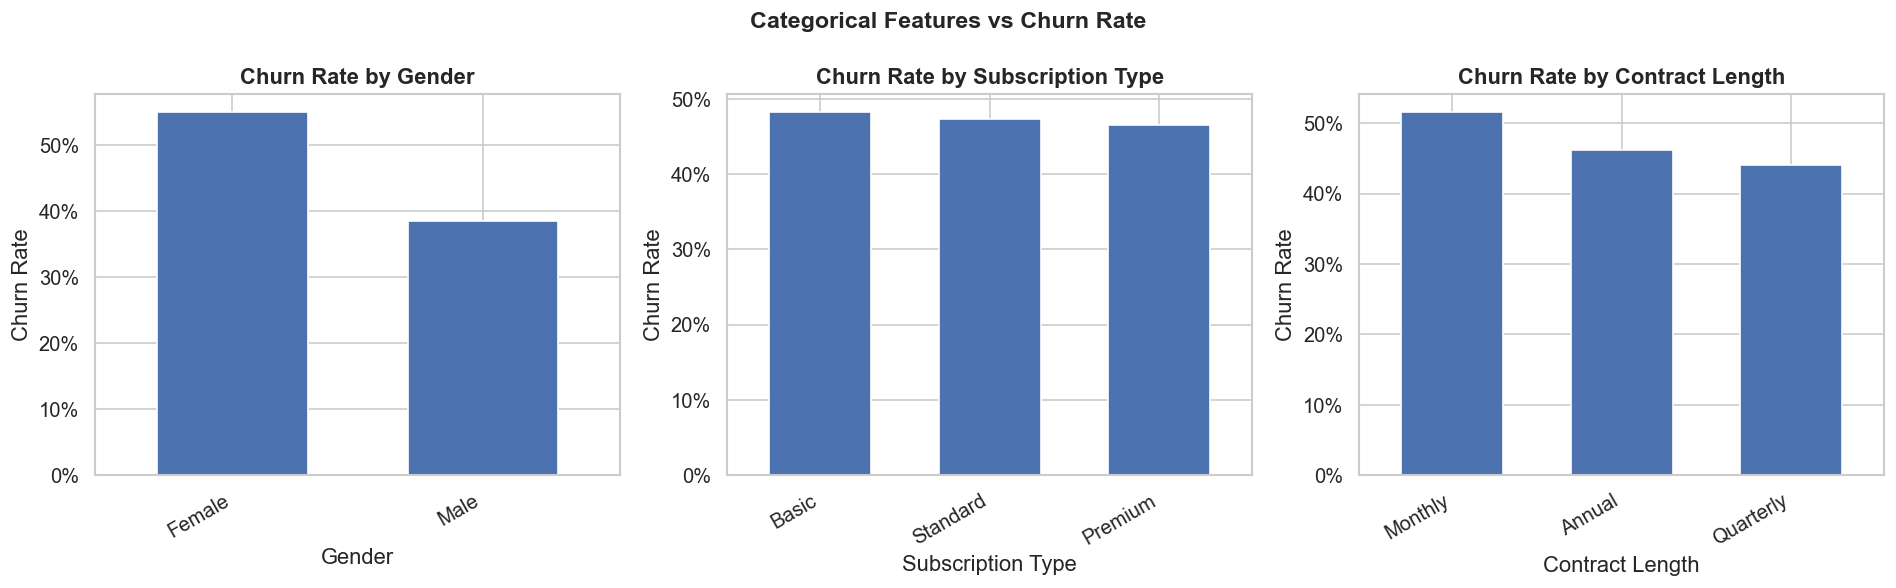

In [6]:
cat_cols = ['Gender', 'Subscription Type', 'Contract Length']
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for i, col in enumerate(cat_cols):
    churn_rate = df.groupby(col)['Churn'].mean().sort_values(ascending=False)
    churn_rate.plot(kind='bar', ax=axes[i], color='#4C72B0', edgecolor='white', width=0.6)
    axes[i].set_title(f'Churn Rate by {col}', fontweight='bold')
    axes[i].set_ylabel('Churn Rate')
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=30, ha='right')
    axes[i].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
plt.suptitle('Categorical Features vs Churn Rate', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('03_categorical_vs_churn.png', bbox_inches='tight')
plt.show()

## Correlation Heatmap

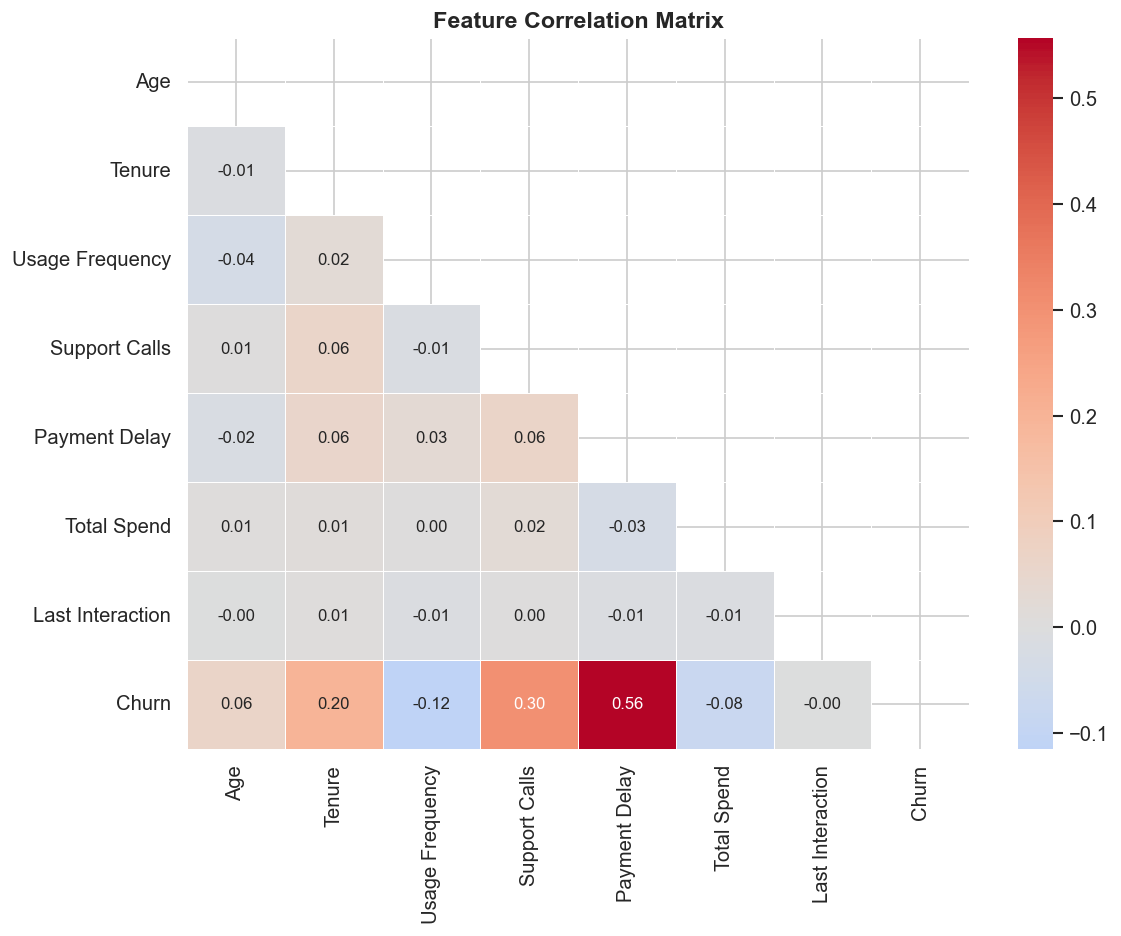

Churn               1.000000
Payment Delay       0.557386
Support Calls       0.304631
Tenure              0.195327
Age                 0.063457
Last Interaction   -0.002818
Total Spend        -0.078867
Usage Frequency    -0.115098
Name: Churn, dtype: float64


In [7]:
fig, ax = plt.subplots(figsize=(10, 8))
corr = df[num_cols + ['Churn']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax, annot_kws={'size': 10})
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('04_correlation_heatmap.png', bbox_inches='tight')
plt.show()
print(corr['Churn'].sort_values(ascending=False))

## Feature Engineering

In [8]:
df_eng = df.copy()
le = LabelEncoder()
df_eng['Gender_enc']       = le.fit_transform(df_eng['Gender'])
df_eng['Subscription_enc'] = le.fit_transform(df_eng['Subscription Type'])
df_eng['Contract_enc']     = le.fit_transform(df_eng['Contract Length'])
df_eng['Calls_per_Month']  = df_eng['Support Calls'] / (df_eng['Tenure'] + 1)
df_eng['Spend_per_Month']  = df_eng['Total Spend'] / (df_eng['Tenure'] + 1)
df_eng['Engagement_Score'] = df_eng['Usage Frequency'] * df_eng['Tenure']
df_eng['Risk_Score']       = df_eng['Support Calls'] + df_eng['Payment Delay']
print(f'Features: {df.shape[1]-1} -> {df_eng.shape[1]-1}')
df_eng.head()

Features: 11 -> 18


,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn,Gender_enc,Subscription_enc,Contract_enc,Calls_per_Month,Spend_per_Month,Engagement_Score,Risk_Score
0,1,22,Female,25,14,4,27,Basic,Monthly,598,9,1,0,0,1,0.153846,23.000000,350,31
1,2,41,Female,28,28,7,13,Standard,Monthly,584,20,0,0,2,1,0.241379,20.137931,784,20
2,3,47,Male,27,10,2,29,Premium,Annual,757,21,0,1,1,0,0.071429,27.035714,270,31
3,4,35,Male,9,12,5,17,Premium,Quarterly,232,18,0,1,1,2,0.500000,23.200000,108,22
4,5,53,Female,58,24,9,2,Standard,Annual,533,18,0,0,2,0,0.152542,9.033898,1392,11


## Preprocessing

In [9]:
drop_cols = ['CustomerID', 'Gender', 'Subscription Type', 'Contract Length', 'Churn']
X = df_eng.drop(columns=drop_cols)
y = df_eng['Churn']
feature_names = list(X.columns)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)
print(f'Train: {X_train.shape} | Test: {X_test.shape}')

Train: (51499, 14) | Test: (12875, 14)


## Train 5 Models

In [16]:
models = {
    'Logistic Regression' : (LogisticRegression(max_iter=1000, random_state=RANDOM_STATE), True),
    'Random Forest'       : (RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1), False),
    'Gradient Boosting'   : (GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, max_depth=5, random_state=RANDOM_STATE), False),
    'Extra Trees'         : (ExtraTreesClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1), False),
    'SVM'                 : (SVC(probability=True, random_state=RANDOM_STATE), True),
}
results, trained_models, all_preds = [], {}, {}
print(f'{"Model":<25} {"Accuracy":>10} {"F1":>8} {"ROC-AUC":>10}')
print('-' * 55)
for name, (model, scaled) in models.items():
    Xtr = X_train_s if scaled else X_train.values
    Xte = X_test_s  if scaled else X_test.values
    model.fit(Xtr, y_train)
    y_pred = model.predict(Xte)
    y_prob = model.predict_proba(Xte)[:, 1]
    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)
    results.append({'Model': name, 'Accuracy': acc, 'F1': f1, 'ROC-AUC': roc})
    trained_models[name] = (model, scaled)
    all_preds[name]      = (y_pred, y_prob)
    print(f'{name:<25} {acc:>10.4f} {f1:>8.4f} {roc:>10.4f}')
results_df = pd.DataFrame(results)
best_name  = results_df.loc[results_df['ROC-AUC'].idxmax(), 'Model']
print(f'\nBest Model: {best_name}')

Model                       Accuracy       F1    ROC-AUC
-------------------------------------------------------
Logistic Regression           0.8277   0.8194     0.9053
Random Forest                 0.9974   0.9972     1.0000
Gradient Boosting             1.0000   1.0000     1.0000
Extra Trees                   0.9862   0.9855     0.9993
SVM                           0.9417   0.9396     0.9889

Best Model: Gradient Boosting


## Cross Validation

In [17]:
best_obj, best_scaled = trained_models[best_name]
cv_X = X_train_s if best_scaled else X_train.values
skf  = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_acc = cross_val_score(best_obj, cv_X, y_train, cv=skf, scoring='accuracy')
cv_f1  = cross_val_score(best_obj, cv_X, y_train, cv=skf, scoring='f1')
cv_roc = cross_val_score(best_obj, cv_X, y_train, cv=skf, scoring='roc_auc')
print(f'5-Fold CV — {best_name}')
print(f'Accuracy : {cv_acc.mean():.4f} +/- {cv_acc.std():.4f}')
print(f'F1 Score : {cv_f1.mean():.4f} +/- {cv_f1.std():.4f}')
print(f'ROC-AUC  : {cv_roc.mean():.4f} +/- {cv_roc.std():.4f}')

5-Fold CV — Gradient Boosting
Accuracy : 0.9999 +/- 0.0000
F1 Score : 0.9999 +/- 0.0000
ROC-AUC  : 1.0000 +/- 0.0000


## ROC Curves

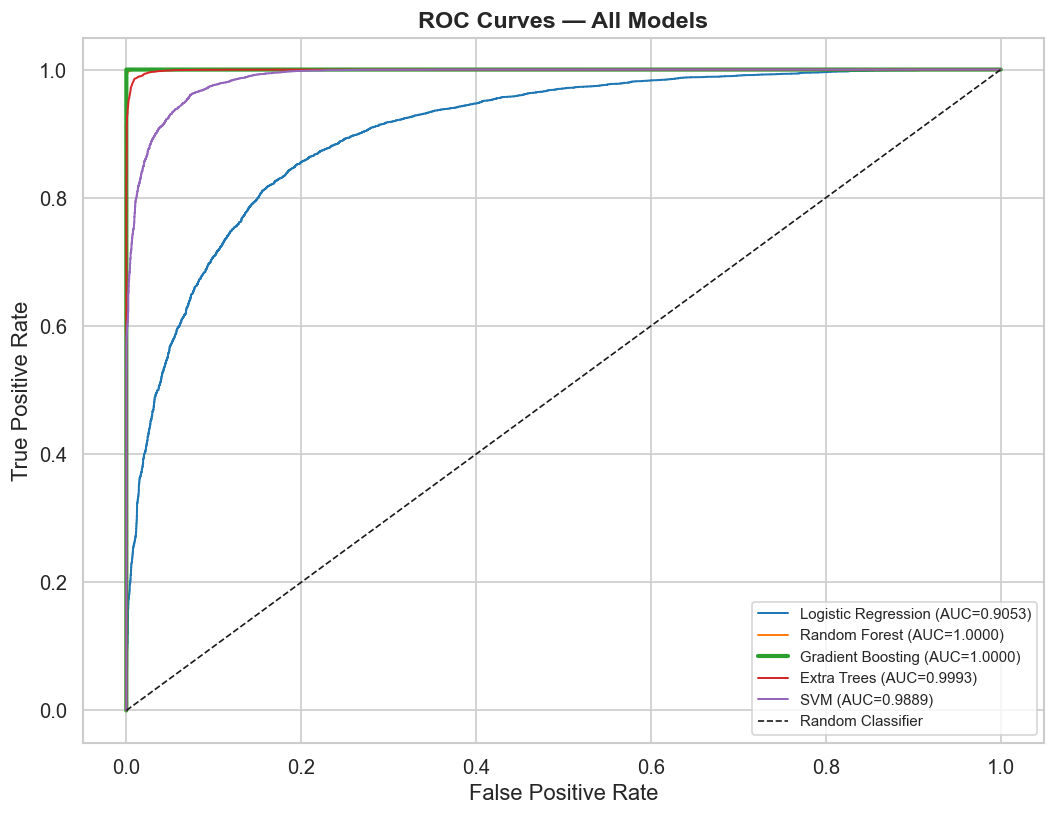

In [18]:
fig, ax = plt.subplots(figsize=(9, 7))
palette = sns.color_palette('tab10', len(models))
for i, (name, (y_pred, y_prob)) in enumerate(all_preds.items()):
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, lw=2.5 if name==best_name else 1.2, color=palette[i], label=f'{name} (AUC={auc:.4f})')
ax.plot([0,1],[0,1], 'k--', lw=1, label='Random Classifier')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — All Models', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig('06_roc_curves.png', bbox_inches='tight')
plt.show()

## Confusion Matrix

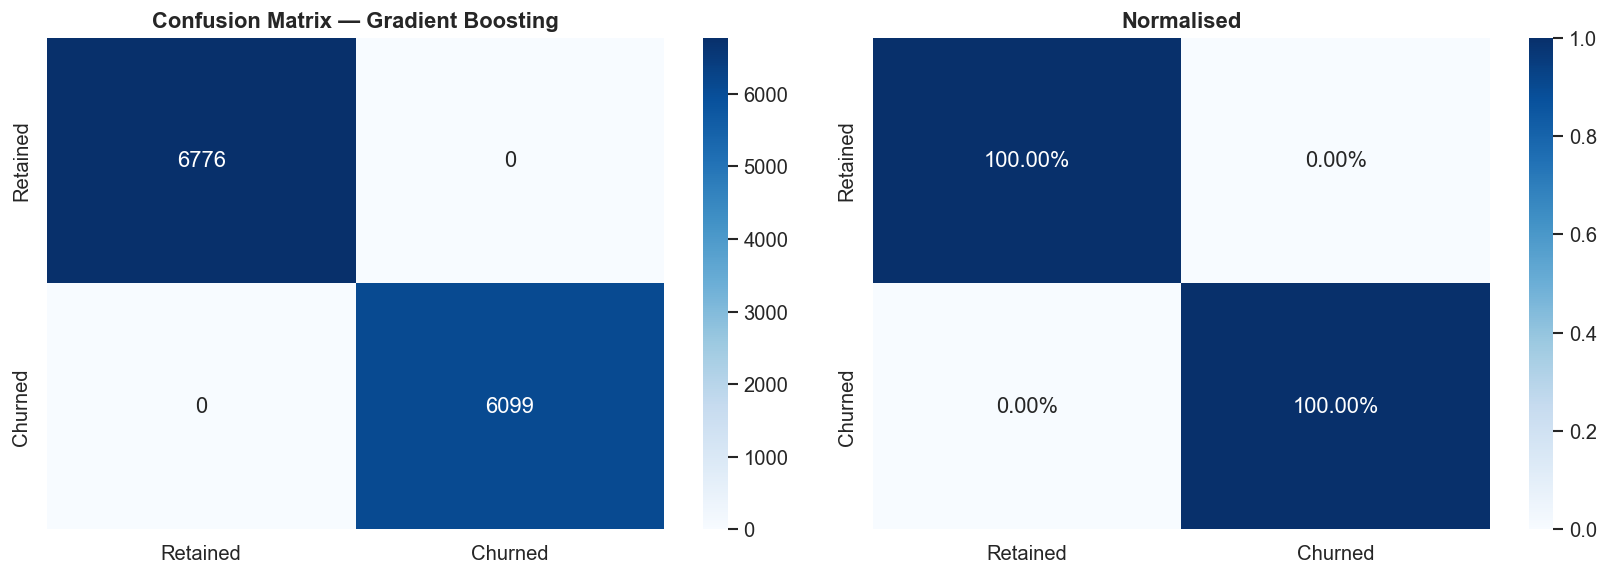

              precision    recall  f1-score   support

    Retained       1.00      1.00      1.00      6776
     Churned       1.00      1.00      1.00      6099

    accuracy                           1.00     12875
   macro avg       1.00      1.00      1.00     12875
weighted avg       1.00      1.00      1.00     12875



In [19]:
best_pred, best_prob = all_preds[best_name]
cm = confusion_matrix(y_test, best_pred)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Retained','Churned'], yticklabels=['Retained','Churned'])
axes[0].set_title(f'Confusion Matrix — {best_name}', fontweight='bold')
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues', ax=axes[1],
            xticklabels=['Retained','Churned'], yticklabels=['Retained','Churned'])
axes[1].set_title('Normalised', fontweight='bold')
plt.tight_layout()
plt.savefig('07_confusion_matrix.png', bbox_inches='tight')
plt.show()
print(classification_report(y_test, best_pred, target_names=['Retained', 'Churned']))

## SHAP

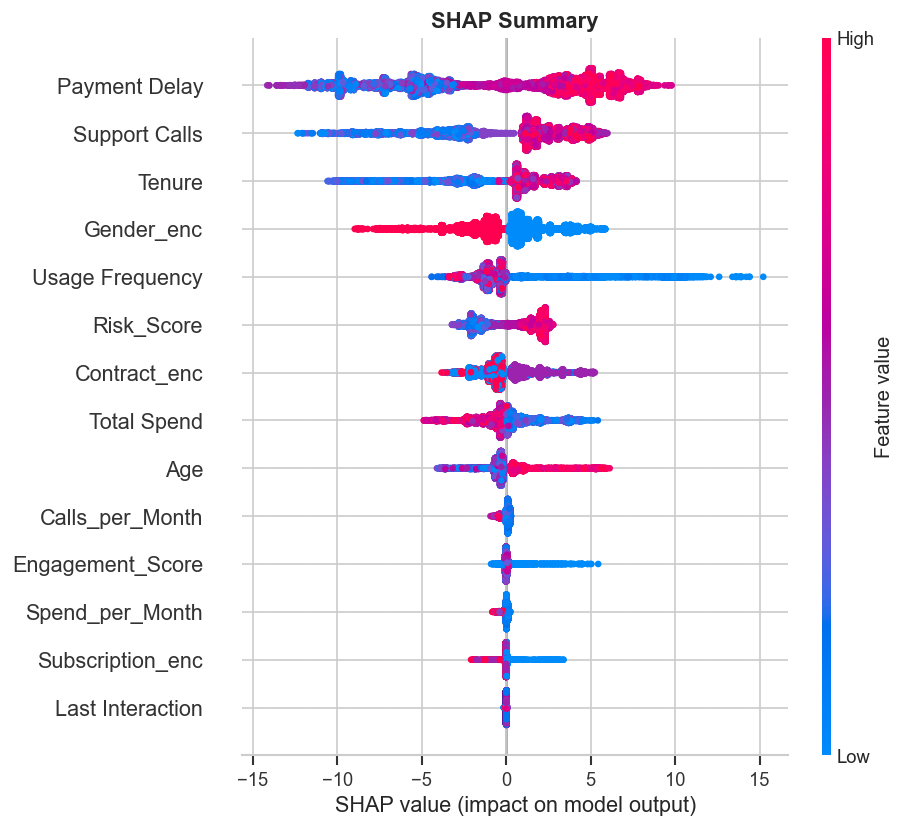

In [21]:
import shap
best_obj_shap, best_scaled_shap = trained_models[best_name]
X_test_shap = X_test_s if best_scaled_shap else X_test.values
if hasattr(best_obj_shap, 'feature_importances_'):
    explainer   = shap.TreeExplainer(best_obj_shap)
    shap_values = explainer.shap_values(X_test_shap)
    sv = shap_values[1] if isinstance(shap_values, list) else shap_values
else:
    explainer   = shap.LinearExplainer(best_obj_shap, X_test_shap)
    sv = explainer.shap_values(X_test_shap)
plt.figure(figsize=(10, 7))
shap.summary_plot(sv, X_test_shap, feature_names=feature_names, show=False)
plt.title('SHAP Summary', fontweight='bold')
plt.tight_layout()
plt.savefig('08_shap_summary.png', bbox_inches='tight')
plt.show()

## Save & Predict

In [ ]:
os.makedirs('models', exist_ok=True)
joblib.dump(best_obj,  'models/best_model.pkl')
joblib.dump(scaler,        'models/scaler.pkl')
joblib.dump(feature_names, 'models/feature_names.pkl')
results_df.to_csv('models/model_comparison.csv', index=False)
print('✅ Saved!')

def predict_churn(age, tenure, usage_frequency, support_calls, payment_delay,
                  total_spend, last_interaction, gender='Male',
                  subscription_type='Basic', contract_length='Monthly'):
    model  = joblib.load('models/best_model.pkl')
    sc     = joblib.load('models/scaler.pkl')
    fnames = joblib.load('models/feature_names.pkl')
    sub_map = {'Basic':0,'Standard':1,'Premium':2}
    con_map = {'Monthly':1,'Quarterly':2,'Annual':0}
    row = pd.DataFrame([[
        age, tenure, usage_frequency, support_calls, payment_delay, total_spend,
        last_interaction, 1 if gender=='Male' else 0,
        sub_map.get(subscription_type,0), con_map.get(contract_length,1),
        support_calls/(tenure+1), total_spend/(tenure+1),
        usage_frequency*tenure, support_calls+payment_delay
    ]], columns=fnames)
    prob = model.predict_proba(sc.transform(row))[0][1]
    print(f'Churn Probability: {prob:.1%}  ->  {"WILL CHURN" if prob>=0.5 else "WILL STAY ✅"}')
    return prob

# Test it
predict_churn(35, 6, 2, 8, 20, 300, 45, subscription_type='Basic', contract_length='Monthly')

✅ Saved!
Churn Probability: 100.0%  ->  WILL CHURN ⚠️


np.float64(0.9999998880781958)